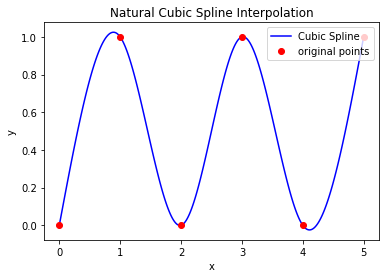

In [8]:
import numpy as np
import matplotlib.pyplot as plt


def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes between data points

    # Initialize the tridiagonal matrix coefficients
    a = np.zeros(n - 2)  # Subdiagonal
    b = np.zeros(n - 2)  # Main diagonal
    c = np.zeros(n - 2)  # Superdiagonal
    d = np.zeros(n - 2)  # Right-hand side vector

    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        a[i - 1] = h[i - 1]                     # Subdiagonal
        b[i - 1] = 2 * (h[i - 1] + h[i])        # Main diagonal
        c[i - 1] = h[i]                         # Superdiagonal
        d[i - 1] = 6 * ((y[i + 1] - y[i]) 
                        / h[i] - (y[i] - y[i - 1])
                        / h[i - 1])     # right hand side vector   

    return a, b, c, d


def thomas_algorithm(a, b, c, d):
    
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x1 = np.zeros(n)
    x1[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x1[i] = (d[i] - c[i] * x1[i+1]) / b[i]
    return x1


def find_coefficients(x, y, M):
    n = len(x)
    A = np.zeros(n - 1)
    B = np.zeros(n - 1)
    C = np.zeros(n - 1)
    D = np.zeros(n - 1)
    
    h = np.diff(x)
    
    for i in range(0, n - 1):
        A[i] = y[i]
        B[i] = ((y[i + 1] - y[i]) / h[i]) - ((h[i]*(2*M[i]+ M[i+1])) / 6)
        C[i] = M[i] / 2
        D[i] = (M[i + 1] - M[i]) / (6 * h[i])
    
    return A, B, C, D


def plot_spline(x, y, A, B, C, D):
        
    for i in range(len(A)):
        # generate smooth x values for smooth plot
        x_smooth = np.linspace(x[i], x[i+1], 100)
        
        # spline formula: S(x) = A + B(x-x_i) + C(x-x_i)^2 + D(x-x_i)^3
        y_smooth = A[i] + B[i]*(x_smooth - x[i]) + \
        C[i]*((x_smooth - x[i])**2) + \
        D[i]*((x_smooth - x[i])**3)
        
        # plot new spline points
        if i == 0:
            plt.plot(x_smooth, y_smooth, color= 'blue',label='Cubic Spline')
        else:
            plt.plot(x_smooth, y_smooth, color='blue')
            
        
    # plot original points
    plt.plot(x, y, "ro",  label = "original points")
        
    plt.title('Natural Cubic Spline Interpolation')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()
    

def evaluate_spline(x_eval, x, y, A, B, C, D):
    
    i = np.searchsorted(x, x_eval) - 1
    
    if i < 0: i = 0
    if i >= len(A): i = len(A) - 1
        
    dx = x_eval - x[i]     
        
    result = A[i] + B[i]*dx + C[i]*(dx**2) + D[i]*(dx**3)
    
    return result
        
    
    

# data points    
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1]) 

# Set up the tridiagonal matrix for the cubic spline
a, b, c, d = setup_tridiagonal_matrix(x, y)

# insert 0 at beginning and end to satisfy natural spline boundary
# conditions
M = thomas_algorithm(a, b, c, d)
M = np.insert(M, 0, 0)
M = np.append(M, 0)

A, B, C, D = find_coefficients(x, y, M)
    
plot_spline(x, y, A, B, C, D)



